In [16]:
import os, cv2, yaml, shutil, pandas as pd
from pycocotools.coco import COCO

BASE_DIR = r"X:\Desktop\kaggle\solar_project_cv"
IMG_DIR = os.path.join(BASE_DIR, r"notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images")
JSON_PATH = os.path.join(BASE_DIR, r"notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json")
FOLDS_CSV = (r"X:\Desktop\kaggle\solar_project_cv\notebooks\clean_fused_folds.csv")
OUT_DIR = os.path.join(BASE_DIR, "yolo_tiled_1024")

TILE = 1024
OVERLAP = 0.20
STRIDE = int(TILE * (1 - OVERLAP))

os.makedirs(os.path.join(OUT_DIR, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "labels", "val"), exist_ok=True)

coco = COCO(JSON_PATH)
df = pd.read_csv(FOLDS_CSV)

name_to_coco_id = {
    img["file_name"]: img["id"]
    for img in coco.dataset["images"]
}

def get_positions(size):
    positions = list(range(0, size - TILE + 1, STRIDE))
    if positions[-1] != size - TILE:
        positions.append(size - TILE)
    return positions

loading annotations into memory...
Done (t=1.08s)
creating index...
index created!


In [17]:
def make_tiles(file_name, split):
    path = os.path.join(IMG_DIR, file_name)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return

    if img.ndim == 3:
        if img.shape[2] == 1:
            img = img[:, :, 0]
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    H, W = img.shape
    xs = get_positions(W)
    ys = get_positions(H)

    coco_id = name_to_coco_id[file_name]
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[coco_id]))

    for row, y0 in enumerate(ys):
        for col, x0 in enumerate(xs):

            tile = img[y0:y0+TILE, x0:x0+TILE]

            tile_name = f"{os.path.splitext(file_name)[0]}_r{row}_c{col}.jpg"
            img_out = os.path.join(OUT_DIR, "images", split, tile_name)
            label_out = os.path.join(OUT_DIR, "labels", split, tile_name.replace(".jpg", ".txt"))

            cv2.imwrite(img_out, tile)

            labels = []

            for ann in anns:
                x, y, bw, bh = ann["bbox"]

                # convert global bbox -> tile coordinates
                tx1 = max(x, x0)
                ty1 = max(y, y0)
                tx2 = min(x + bw, x0 + TILE)
                ty2 = min(y + bh, y0 + TILE)

                # no intersection
                if tx2 <= tx1 or ty2 <= ty1:
                    continue

                # IMPORTANT:
                # We keep the clipped bbox if object intersects tile.
                local_x1 = tx1 - x0
                local_y1 = ty1 - y0
                local_x2 = tx2 - x0
                local_y2 = ty2 - y0

                local_w = local_x2 - local_x1
                local_h = local_y2 - local_y1

                xc = (local_x1 + local_x2) / 2 / TILE
                yc = (local_y1 + local_y2) / 2 / TILE
                wn = local_w / TILE
                hn = local_h / TILE

                labels.append(
                    f"0 {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}"
                )

            with open(label_out, "w") as f:
                f.write("\n".join(labels))

# fold 0 = validation, others = train
for _, row in df.iterrows():
    split = "val" if row["fold"] == 0 else "train"
    make_tiles(row["file_name"], split)

print("Tiled dataset created:", OUT_DIR)

Tiled dataset created: X:\Desktop\kaggle\solar_project_cv\yolo_tiled_1024


In [18]:
yaml_path = os.path.join(OUT_DIR, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump({
        "path": OUT_DIR,
        "train": "images/train",
        "val": "images/val",
        "nc": 1,
        "names": ["filament"]
    }, f, sort_keys=False)

print(yaml_path)

X:\Desktop\kaggle\solar_project_cv\yolo_tiled_1024\data.yaml


In [21]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

# results = model.train(
#     data=yaml_path,
#     epochs=30,
#     imgsz=1280,
#     batch=4,
#     device=0,
#     workers=4,
#     pretrained=True,
#     patience=8,
#     project=os.path.join(BASE_DIR, "models"),
#     name="yolo11m_tiled1024",
#     exist_ok=True,
#     amp=True,
#     plots=True,
#     save=True
# )

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=1024,
    batch=4,
    device=0,
    workers=8,
    pretrained=True,
    patience=8,
    project=os.path.join(BASE_DIR, "models"),
    name="yolo11m_tiled_1024",
    exist_ok=True,
    amp=True,
    cache=True,
    plots=True,
    save=True
)

New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.217  Python-3.10.14 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=X:\Desktop\kaggle\solar_project_cv\yolo_tiled_1024\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scal

In [22]:
def tiled_detect(image, model, conf=0.30, nms_iou=0.5):
    H, W = image.shape[:2]
    xs = get_positions(W)
    ys = get_positions(H)

    all_boxes = []

    for y0 in ys:
        for x0 in xs:
            tile = image[y0:y0+TILE, x0:x0+TILE]

            if tile.ndim == 2:
                tile_bgr = cv2.cvtColor(tile, cv2.COLOR_GRAY2BGR)
            else:
                tile_bgr = tile

            result = model.predict(
                tile_bgr,
                imgsz=1280,
                conf=conf,
                iou=0.5,
                verbose=False
            )[0]

            if result.boxes is None:
                continue

            boxes = result.boxes.xyxy.cpu().numpy()
            scores = result.boxes.conf.cpu().numpy()

            for box, score in zip(boxes, scores):
                x1, y1, x2, y2 = box

                # tile coordinates -> original image coordinates
                x1 += x0
                x2 += x0
                y1 += y0
                y2 += y0

                all_boxes.append({
                    "box": [x1, y1, x2, y2],
                    "score": float(score)
                })

    return apply_extra_nms(all_boxes, nms_iou)

In [23]:
YOLO_PATH = os.path.join(
    BASE_DIR,
    r"models\yolo11m_tiled_1024\weights\best.pt"
)

In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import segmentation_models_pytorch as smp
from ultralytics import YOLO
from pycocotools import mask as maskUtils

# ============================================================
# PATHS
# ============================================================


TEST_DIR = os.path.join(
    BASE_DIR,
    r"notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
)

SEG_DIR = os.path.join(BASE_DIR, "models")

OUTPUT_CSV = os.path.join(BASE_DIR, "submission_tiled.csv")

# ============================================================
# SETTINGS
# ============================================================

TILE = 1024
OVERLAP = 0.20
STRIDE = int(TILE * (1 - OVERLAP))

YOLO_IMGSZ = 1024
YOLO_CONF = 0.30
YOLO_IOU = 0.50

GLOBAL_NMS_IOU = 0.50

CROP_PAD = 0.20
MASK_THR = 0.50

NUM_FOLDS = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("YOLO:", YOLO_PATH)

# ============================================================
# TILE POSITIONS
# ============================================================

def get_positions(size):
    if size <= TILE:
        return [0]

    positions = list(range(0, size - TILE + 1, STRIDE))

    if positions[-1] != size - TILE:
        positions.append(size - TILE)

    return positions

# ============================================================
# GLOBAL NMS
# ============================================================

def box_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0.0


def global_nms(detections, iou_thr=0.5):
    if not detections:
        return []

    detections = sorted(
        detections,
        key=lambda x: x["score"],
        reverse=True
    )

    keep = []

    while detections:
        best = detections.pop(0)
        keep.append(best)

        remaining = []

        for det in detections:
            iou = box_iou(best["box"], det["box"])

            if iou <= iou_thr:
                remaining.append(det)

        detections = remaining

    return keep

Device: cuda
YOLO: X:\Desktop\kaggle\solar_project_cv\models\yolo11m_tiled_1024\weights\best.pt


In [26]:
# ============================================================
# LOAD YOLO
# ============================================================

detector = YOLO(YOLO_PATH)

print("YOLO loaded")

# ============================================================
# LOAD 5 U-NET MODELS
# ============================================================

seg_models = []

for fold in range(NUM_FOLDS):

    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1
    )

    weight_path = os.path.join(
        SEG_DIR,
        f"best_seg_resnet34_fold_{fold}.pth"
    )

    model.load_state_dict(
        torch.load(weight_path, map_location=DEVICE)
    )

    model.to(DEVICE)
    model.eval()

    seg_models.append(model)

    print(f"Loaded U-Net fold {fold}")

YOLO loaded
Loaded U-Net fold 0
Loaded U-Net fold 1
Loaded U-Net fold 2
Loaded U-Net fold 3
Loaded U-Net fold 4


In [29]:
# ============================================================
# SEGMENT ONE CROP
# ============================================================

def segment_crop(crop):

    # grayscale
    if crop.ndim == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(crop)

    # normalize
    img = enhanced.astype(np.float32) / 255.0

    # 3 channels
    img = np.stack([img, img, img], axis=0)

    tensor = torch.from_numpy(img).unsqueeze(0).float().to(DEVICE)

    predictions = []

    with torch.no_grad():
        for model in seg_models:
            pred = torch.sigmoid(model(tensor))
            predictions.append(pred[0, 0].cpu().numpy())

    # ensemble mean
    pred = np.mean(predictions, axis=0)

    return pred

# ============================================================
# PROCESS ONE TEST IMAGE
# ============================================================

def process_image(image_path):
    raw = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

    if raw is None:
        print("Could not read:", image_path)
        return []

        # Safety: force grayscale to 2D
    if raw.ndim == 3:
        raw = raw[:, :, 0]

    H, W = raw.shape
    # raw = cv2.imread(
    #     image_path,
    #     cv2.IMREAD_GRAYSCALE
    # )

    # if raw is None:
    #     print("Could not read:", image_path)
    #     return []

    # H, W = raw.shape

    # --------------------------------------------------------
    # Solar disk preprocessing for YOLO
    # --------------------------------------------------------

    disk_mask = raw > 15

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(raw)

    yolo_image = cv2.cvtColor(
        enhanced,
        cv2.COLOR_GRAY2BGR
    )

    # --------------------------------------------------------
    # TILED YOLO DETECTION
    # --------------------------------------------------------

    xs = get_positions(W)
    ys = get_positions(H)

    detections = []

    for y0 in ys:
        for x0 in xs:

            tile = yolo_image[
                y0:y0 + TILE,
                x0:x0 + TILE
            ]

            result = detector.predict(
                tile,
                imgsz=YOLO_IMGSZ,
                conf=YOLO_CONF,
                iou=YOLO_IOU,
                verbose=False
            )[0]

            if result.boxes is None:
                continue

            if len(result.boxes) == 0:
                continue

            boxes = result.boxes.xyxy.cpu().numpy()
            scores = result.boxes.conf.cpu().numpy()

            for box, score in zip(boxes, scores):

                x1, y1, x2, y2 = box

                # YOLO coordinates are already in tile coordinates
                # Convert to global image coordinates
                x1 += x0
                x2 += x0
                y1 += y0
                y2 += y0

                # Clip to image
                x1 = max(0, min(W, x1))
                x2 = max(0, min(W, x2))
                y1 = max(0, min(H, y1))
                y2 = max(0, min(H, y2))

                if x2 <= x1 or y2 <= y1:
                    continue

                detections.append({
                    "box": [x1, y1, x2, y2],
                    "score": float(score)
                })

    print(
        f"{os.path.basename(image_path)}: "
        f"{len(detections)} raw detections"
    )

    # --------------------------------------------------------
    # GLOBAL NMS
    # --------------------------------------------------------

    detections = global_nms(
        detections,
        iou_thr=GLOBAL_NMS_IOU
    )

    print(
        f"  after global NMS: {len(detections)}"
    )

    # Highest confidence first
    detections = sorted(
        detections,
        key=lambda x: x["score"],
        reverse=True
    )

    # --------------------------------------------------------
    # PANOPTIC PAINTING
    # --------------------------------------------------------

    occupied = np.zeros(
        (H, W),
        dtype=np.uint8
    )

    instances = []

    for det in detections:

        x1, y1, x2, y2 = det["box"]

        bw = float(x2 - x1)
        bh = float(y2 - y1)

        # 20% padding
        x1p = max(
            0,
            int(round(x1 - bw * CROP_PAD))
        )

        y1p = max(
            0,
            int(round(y1 - bh * CROP_PAD))
        )

        x2p = min(
            W,
            int(round(x2 + bw * CROP_PAD))
        )

        y2p = min(
            H,
            int(round(y2 + bh * CROP_PAD))
        )

        if x2p <= x1p or y2p <= y1p:
            continue

        crop = raw[y1p:y2p, x1p:x2p]

        if crop.size == 0:
            continue

        # Resize to U-Net input
        crop_512 = cv2.resize(
            crop,
            (512, 512),
            interpolation=cv2.INTER_AREA
        )

        pred = segment_crop(crop_512)

        mask_small = (
            pred > MASK_THR
        ).astype(np.uint8)

        if mask_small.sum() == 0:
            continue

        # Resize mask back to padded crop
        mask_crop = cv2.resize(
            mask_small,
            (x2p - x1p, y2p - y1p),
            interpolation=cv2.INTER_NEAREST
        )

        # Put into global coordinates
        mask_global = np.zeros(
            (H, W),
            dtype=np.uint8
        )

        mask_global[
            y1p:y2p,
            x1p:x2p
        ] = mask_crop

        # ----------------------------------------------------
        # Panoptic Painting
        # Prevent overlapping predicted instances
        # ----------------------------------------------------

        mask_global[
            occupied > 0
        ] = 0

        if mask_global.sum() == 0:
            continue

        occupied[
            mask_global > 0
        ] = 1

        instances.append({
            "mask": mask_global,
            "score": det["score"]
        })

    return instances


In [ ]:
# ============================================================
# CREATE SUBMISSION
# ============================================================

submission_data = []

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
])

print("Test images:", len(test_files))

for image_idx, filename in enumerate(test_files):

    image_path = os.path.join(
        TEST_DIR,
        filename
    )

    instances = process_image(image_path)

    image_id = os.path.splitext(filename)[0]

    accepted_id = 1

    for instance in instances:

        mask = instance["mask"]

        rle = maskUtils.encode(
            np.asfortranarray(mask)
        )

        rle["counts"] = rle["counts"].decode("utf-8")

        submission_data.append({
            "filament_id": f"{image_id}_{accepted_id}",
            "segmentation_rle": rle["counts"]
        })

        accepted_id += 1

    if (image_idx + 1) % 25 == 0:
        print(
            f"Processed {image_idx + 1}/{len(test_files)}"
        )


print("\nSubmission saved:")
print(OUTPUT_CSV)

Test images: 180
20110120105534Ch.jpeg: 3 raw detections
  after global NMS: 2
20110130110334Ch.jpeg: 2 raw detections
  after global NMS: 1
20110214175414Mh.jpeg: 11 raw detections
  after global NMS: 4
20110329082654Uh.jpeg: 22 raw detections
  after global NMS: 9
20110408083214Th.jpeg: 27 raw detections
  after global NMS: 14
20110424064534Lh.jpeg: 16 raw detections
  after global NMS: 9
20110429120534Ch.jpeg: 30 raw detections
  after global NMS: 15
20110529063154Uh.jpeg: 23 raw detections
  after global NMS: 9
20110531070514Th.jpeg: 15 raw detections
  after global NMS: 7
20110603123034Ch.jpeg: 26 raw detections
  after global NMS: 14
20110706164014Mh.jpeg: 12 raw detections
  after global NMS: 5
20110811121534Ch.jpeg: 37 raw detections
  after global NMS: 18
20110819131834Ch.jpeg: 15 raw detections
  after global NMS: 8
20110827141254Bh.jpeg: 12 raw detections
  after global NMS: 5
20110912142254Bh.jpeg: 27 raw detections
  after global NMS: 12
20111015063134Lh.jpeg: 24 raw detec

NameError: name 'submission' is not defined

In [31]:
# ============================================================
# SAVE
# ============================================================

submission = pd.DataFrame(
    submission_data,
    columns=[
        "filament_id",
        "segmentation_rle"
    ]
)

if len(submission) > 0:
    assert submission["filament_id"].is_unique


In [33]:
submission.shape

(1558, 2)

In [34]:
submission.to_csv(
    OUTPUT_CSV,
    index=False
)

In [ ]:
TILE = 1024
OVERLAP = 0.20
STRIDE = int(TILE * (1 - OVERLAP))
YOLO_IMGSZ = 1024
YOLO_CONF = 0.30
YOLO_IOU = 0.50
GLOBAL_NMS_IOU = 0.50

model = YOLO(YOLO_PATH)

def get_positions(size):
    if size <= TILE:
        return [0]
    positions = list(range(0, size - TILE + 1, STRIDE))
    if positions[-1] != size - TILE:
        positions.append(size - TILE)
    return positions

def box_iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    area_a = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    area_b = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0

def global_nms(detections, iou_thr=0.5):
    detections = sorted(detections, key=lambda x: x["score"], reverse=True)
    keep = []
    while detections:
        best = detections.pop(0)
        keep.append(best)
        detections = [
            d for d in detections
            if box_iou(best["box"], d["box"]) <= iou_thr
        ]
    return keep

def tiled_detect(image):
    if image.ndim == 3:
        if image.shape[2] == 1:
            image = image[:, :, 0]
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    H, W = image.shape
    xs = get_positions(W)
    ys = get_positions(H)

    detections = []

    for y0 in ys:
        for x0 in xs:
            tile = image[y0:y0+TILE, x0:x0+TILE]
            tile = cv2.cvtColor(tile, cv2.COLOR_GRAY2BGR)

            result = model.predict(
                tile,
                imgsz=YOLO_IMGSZ,
                conf=YOLO_CONF,
                iou=YOLO_IOU,
                verbose=False
            )[0]

            if result.boxes is None or len(result.boxes) == 0:
                continue

            boxes = result.boxes.xyxy.cpu().numpy()
            scores = result.boxes.conf.cpu().numpy()

            for box, score in zip(boxes, scores):
                x1, y1, x2, y2 = box

                x1 += x0
                x2 += x0
                y1 += y0
                y2 += y0

                detections.append({
                    "box": [x1, y1, x2, y2],
                    "score": float(score)
                })

    raw_count = len(detections)
    detections = global_nms(detections, GLOBAL_NMS_IOU)

    return detections, raw_count

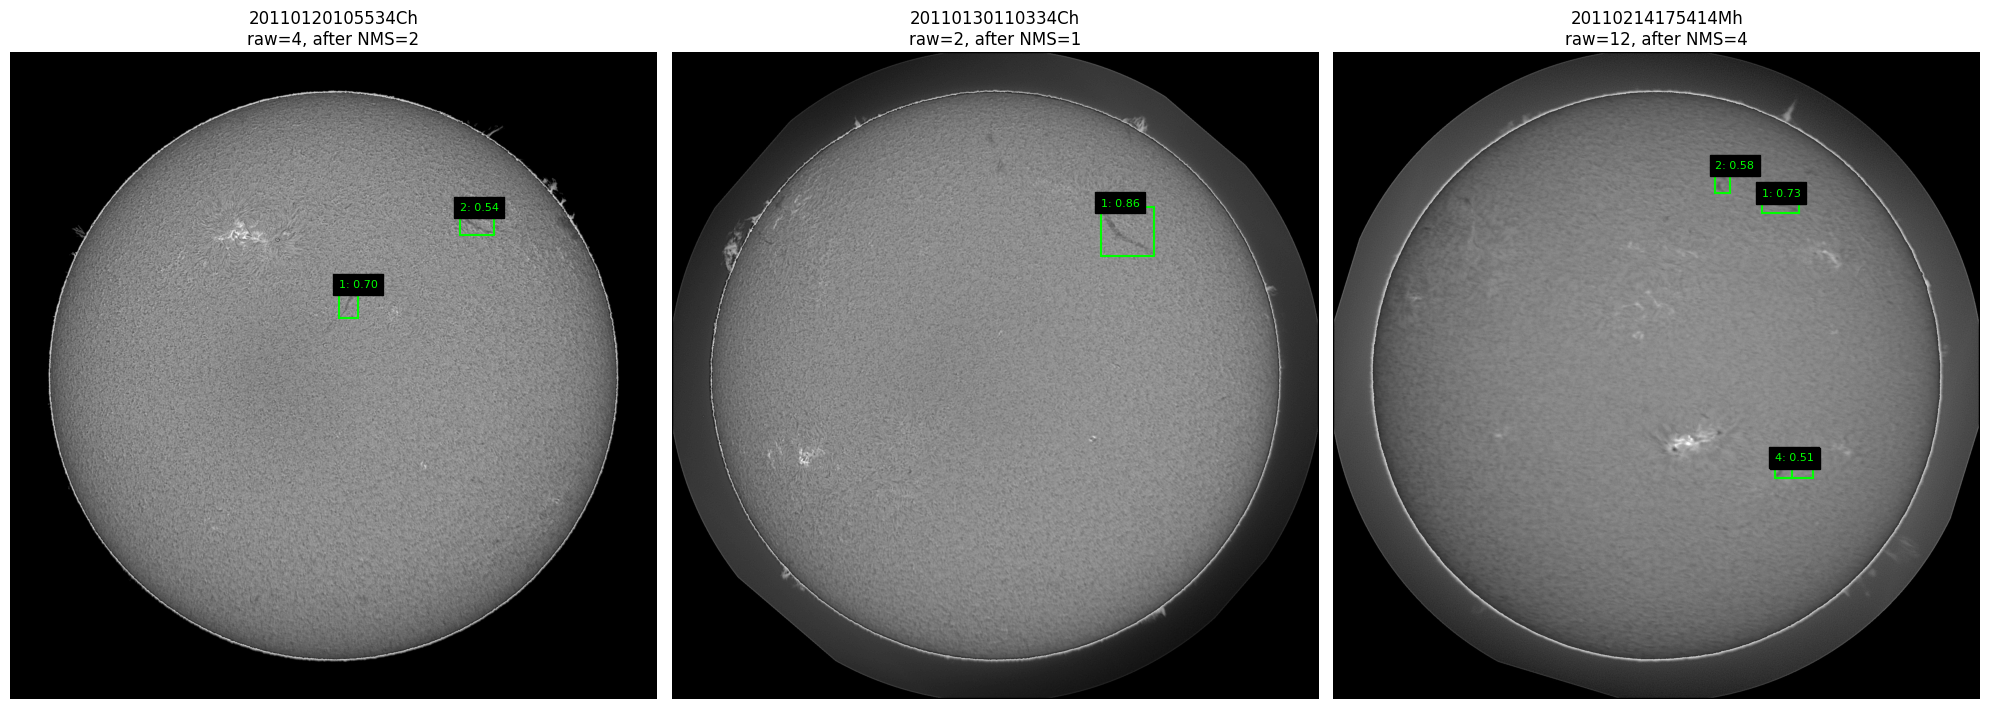

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline


test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# change this to inspect different images
files_to_show = test_files[:3]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 15)
)

axes = axes.flatten()

for ax, filename in zip(axes, files_to_show):

    path = os.path.join(TEST_DIR, filename)
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    detections, raw_count = tiled_detect(image)

    ax.imshow(image, cmap="gray")

    for i, det in enumerate(detections):

        x1, y1, x2, y2 = det["box"]
        score = det["score"]

        rect = plt.Rectangle(
            (x1, y1),
            x2-x1,
            y2-y1,
            fill=False,
            edgecolor="lime",
            linewidth=1.5
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1 - 5,
            f"{i+1}: {score:.2f}",
            color="lime",
            fontsize=8,
            backgroundcolor="black"
        )

    ax.set_title(
        f"{os.path.splitext(filename)[0]}\n"
        f"raw={raw_count}, after NMS={len(detections)}"
    )

    ax.axis("off")

for ax in axes[len(files_to_show):]:
    ax.axis("off")

plt.tight_layout()
plt.show()